# DATA VORTEX — Round 1 Phase 1
## Dataset 01 — Data Intake Restoration

### Objective
Recover, audit, clean, validate, and analyze the corrupted Social Engine dataset.

### Method
Observe → Test → Validate → Decide → Transform → Validate Again

### Important Rule
The original recovered datasets will never be modified directly.

In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Pandas version: 2.3.3
NumPy version: 2.3.5


In [162]:
from pathlib import Path

# Current project folder
BASE_DIR = Path.cwd()

# Raw dataset files
POSTS_PATH = BASE_DIR / "Social_Engine_Posts_Corrupted.csv"
USERS_PATH = BASE_DIR / "Social_Engine_Users.csv"

print("Current working directory:", BASE_DIR)
print("Posts file exists:", POSTS_PATH.exists())
print("Users file exists:", USERS_PATH.exists())

Current working directory: c:\Users\Aryan Kishore\OneDrive\Desktop\QUANTUM ALPHA\DATA_VORTEX
Posts file exists: True
Users file exists: True


In [163]:
print(list(BASE_DIR.iterdir()))

[WindowsPath('c:/Users/Aryan Kishore/OneDrive/Desktop/QUANTUM ALPHA/DATA_VORTEX/Social_Engine_Posts_Cleaned.csv'), WindowsPath('c:/Users/Aryan Kishore/OneDrive/Desktop/QUANTUM ALPHA/DATA_VORTEX/Social_Engine_Posts_Corrupted.csv'), WindowsPath('c:/Users/Aryan Kishore/OneDrive/Desktop/QUANTUM ALPHA/DATA_VORTEX/Social_Engine_Users.csv')]


In [164]:
# STEP 3 — Load raw datasets

posts_raw = pd.read_csv(POSTS_PATH)
users_raw = pd.read_csv(USERS_PATH)

print("Posts loaded successfully.")
print("Users loaded successfully.")

Posts loaded successfully.
Users loaded successfully.


In [165]:
# Verify loaded datasets

print("Posts shape:", posts_raw.shape)
print("Users shape:", users_raw.shape)

Posts shape: (12360, 8)
Users shape: (1500, 5)


In [166]:
# STEP 4 — Inspect raw schema and first records

print("===== POSTS: COLUMN NAMES =====")
print(posts_raw.columns.tolist())

print("\n===== USERS: COLUMN NAMES =====")
print(users_raw.columns.tolist())

print("\n===== POSTS: FIRST 5 ROWS =====")
display(posts_raw.head())

print("\n===== USERS: FIRST 5 ROWS =====")
display(users_raw.head())

===== POSTS: COLUMN NAMES =====
['post_id', 'user_id', 'platform', 'text_content', 'timestamp', 'likes', 'shares', 'comments']

===== USERS: COLUMN NAMES =====
['user_id', 'location', 'language', 'account_created', 'follower_count']

===== POSTS: FIRST 5 ROWS =====


,post_id,user_id,platform,text_content,timestamp,likes,shares,comments
0,to64mgey2v3y,user_vfxs1pry,Reddit,Bummed out with my new Air Max from Nike! Abso...,25-09-2024,4488.0,1456,673
1,7f0wdauzbj89,user_8l7rv5oe,Reddit,My one month review of Pepsi Crystal Pepsi: Hi...,1722528840,789.0,1484,39
2,dvvhg8eel45x,user_nfo3ih5u,NaN,Just unboxed my new Highlander from Toyota. Ex...,2025-04-13T20:12:18,NaN,1410,839
3,hgb9cxke4t7b,user_27aje6ur,Facebook,Comparing Pepsi Crystal Pepsi to the competiti...,10-09-2024,167.0,584,833
4,zwerpw3wk320,user_9px5q0by,Reddit,My one week review of Coca-Cola Diet Coke: Bes...,31-05-2024,4749.0,152,630



===== USERS: FIRST 5 ROWS =====


,user_id,location,language,account_created,follower_count
0,user_guglt5jp,"Berlin, Germany",ja,2023-10-23,38963
1,user_b1p3wz81,"Munich, Germany",zh,2023-05-06,24644
2,user_jm2grmis,"Dubai, UAE",en,2023-01-03,45842
3,user_ykoqww5l,"Paris, France",fr,2023-10-11,665
4,user_3zzvv8vp,"Los Angeles, USA",ru,2023-05-23,42908


In [167]:
# STEP 5 — Inspect raw data types

print("===== POSTS DATA TYPES =====")
display(posts_raw.dtypes.to_frame("dtype"))

print("\n===== USERS DATA TYPES =====")
display(users_raw.dtypes.to_frame("dtype"))

===== POSTS DATA TYPES =====


,dtype
post_id,object
user_id,object
platform,object
text_content,object
timestamp,object
likes,float64
shares,int64
comments,int64



===== USERS DATA TYPES =====


,dtype
user_id,object
location,object
language,object
account_created,object
follower_count,int64


In [168]:
# STEP 6 — Raw dataset information

print("===== POSTS INFO =====")
posts_raw.info()

print("\n===== USERS INFO =====")
users_raw.info()

===== POSTS INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12360 entries, 0 to 12359
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   post_id       12360 non-null  object 
 1   user_id       12360 non-null  object 
 2   platform      10514 non-null  object 
 3   text_content  10614 non-null  object 
 4   timestamp     12360 non-null  object 
 5   likes         10502 non-null  float64
 6   shares        12360 non-null  int64  
 7   comments      12360 non-null  int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 772.6+ KB

===== USERS INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   user_id          1500 non-null   object
 1   location         1500 non-null   object
 2   language         1500 non-null   object
 3   account_created

In [169]:
# STEP 7 — Native missing-value counts

print("===== POSTS NATIVE MISSING VALUES =====")
posts_missing = posts_raw.isna().sum().to_frame("missing_count")
posts_missing["missing_%"] = (
    posts_missing["missing_count"] / len(posts_raw) * 100
).round(2)

display(posts_missing)

print("\n===== USERS NATIVE MISSING VALUES =====")
users_missing = users_raw.isna().sum().to_frame("missing_count")
users_missing["missing_%"] = (
    users_missing["missing_count"] / len(users_raw) * 100
).round(2)

display(users_missing)

===== POSTS NATIVE MISSING VALUES =====


,missing_count,missing_%
post_id,0,0.00
user_id,0,0.00
platform,1846,14.94
text_content,1746,14.13
timestamp,0,0.00
likes,1858,15.03
shares,0,0.00
comments,0,0.00



===== USERS NATIVE MISSING VALUES =====


,missing_count,missing_%
user_id,0,0.0
location,0,0.0
language,0,0.0
account_created,0,0.0
follower_count,0,0.0


In [170]:
# STEP 8 — Search for common missing-value sentinels

sentinels = ["NULL", "null", "N/A", "NA", "None", "none", "", " "]

for column in posts_raw.select_dtypes(include="object").columns:
    print(f"\n===== {column} =====")
    
    counts = posts_raw[column].value_counts(dropna=False)
    
    sentinel_counts = counts[
        counts.index.astype(str).isin(sentinels)
    ]
    
    if len(sentinel_counts) > 0:
        display(sentinel_counts.to_frame("count"))
    else:
        print("No tested sentinel values found.")


===== post_id =====
No tested sentinel values found.

===== user_id =====
No tested sentinel values found.

===== platform =====
No tested sentinel values found.

===== text_content =====
No tested sentinel values found.

===== timestamp =====
No tested sentinel values found.


In [171]:
# STEP 9 — Load an audit copy without automatic NA interpretation

posts_audit = pd.read_csv(
    POSTS_PATH,
    keep_default_na=False,
    na_filter=False
)

users_audit = pd.read_csv(
    USERS_PATH,
    keep_default_na=False,
    na_filter=False
)

print("Audit Posts shape:", posts_audit.shape)
print("Audit Users shape:", users_audit.shape)

Audit Posts shape: (12360, 8)
Audit Users shape: (1500, 5)


In [172]:
# STEP 9A — Compare missing values before and after Pandas NA interpretation

print("===== NORMAL LOAD =====")
print(posts_raw[["platform", "text_content", "likes"]].isna().sum())

print("\n===== LITERAL/TOKEN LOAD =====")
print(
    posts_audit[["platform", "text_content", "likes"]]
    .apply(lambda col: (col == "").sum())
)

===== NORMAL LOAD =====
platform        1846
text_content    1746
likes           1858
dtype: int64

===== LITERAL/TOKEN LOAD =====
platform        1219
text_content    1196
likes           1229
dtype: int64


In [173]:
# STEP 9B — Inspect special tokens in the literal CSV representation

for col in ["platform", "text_content", "likes"]:
    print(f"\n===== {col} =====")

    value_counts = posts_audit[col].value_counts(dropna=False)

    suspicious = value_counts[
        value_counts.index.astype(str).str.strip().isin([
            "",
            "NULL",
            "null",
            "N/A",
            "NA",
            "None",
            "none"
        ])
    ]

    if len(suspicious) > 0:
        display(suspicious.to_frame("count"))
    else:
        print("No tested special tokens found.")


===== platform =====


,count
platform,
,1219
NULL,627



===== text_content =====


,count
text_content,
,1196
NULL,550
NULL\n\n,24



===== likes =====


,count
likes,
,1229
NULL,629


In [174]:
# STEP 9C — Detect whitespace-only strings

for col in ["platform", "text_content"]:
    whitespace_only = posts_audit[col].apply(
        lambda x: isinstance(x, str) and x.strip() == "" and x != ""
    ).sum()

    print(f"{col}: whitespace-only values =", whitespace_only)

platform: whitespace-only values = 0
text_content: whitespace-only values = 0


In [175]:
# STEP 9D — Compare raw-token vs Pandas-native missingness

comparison = pd.DataFrame({
    "normal_read_csv_NA": posts_raw[["platform", "text_content", "likes"]].isna().sum(),
    "literal_empty_strings": (
        posts_audit[["platform", "text_content", "likes"]]
        == ""
    ).sum(),
})

display(comparison)

,normal_read_csv_NA,literal_empty_strings
platform,1846,1219
text_content,1746,1196
likes,1858,1229


In [176]:
# STEP 10 — Missingness combination analysis
# Detection only — no values are modified.

cols = ["platform", "text_content", "likes"]

missing_flags = posts_raw[cols].isna()

combination_counts = (
    missing_flags
    .value_counts()
    .rename("row_count")
    .reset_index()
)

print("===== MISSINGNESS COMBINATIONS =====")
display(combination_counts)

===== MISSINGNESS COMBINATIONS =====


,platform,text_content,likes,row_count
0,False,False,False,7647
1,True,False,False,1381
2,False,False,True,1361
3,False,True,False,1274
4,False,True,True,232
5,True,False,True,225
6,True,True,False,200
7,True,True,True,40


In [177]:
# STEP 10A — Missingness rates

missing_summary = pd.DataFrame({
    "missing_count": posts_raw[cols].isna().sum(),
    "missing_percentage": (
        posts_raw[cols].isna().mean() * 100
    ).round(2)
})

display(missing_summary)

,missing_count,missing_percentage
platform,1846,14.94
text_content,1746,14.13
likes,1858,15.03


In [178]:
# STEP 10B — Test independence of missingness

n = len(posts_raw)

p_platform = posts_raw["platform"].isna().mean()
p_text = posts_raw["text_content"].isna().mean()
p_likes = posts_raw["likes"].isna().mean()

expected_all_three = n * p_platform * p_text * p_likes

observed_all_three = (
    posts_raw["platform"].isna()
    & posts_raw["text_content"].isna()
    & posts_raw["likes"].isna()
).sum()

print("Expected all-three missing (independence):",
      round(expected_all_three, 2))

print("Observed all-three missing:",
      observed_all_three)

Expected all-three missing (independence): 39.2
Observed all-three missing: 40


In [179]:
# STEP 10C — Pairwise missingness overlap

missing_platform = posts_raw["platform"].isna()
missing_text = posts_raw["text_content"].isna()
missing_likes = posts_raw["likes"].isna()

pairwise_missingness = pd.DataFrame({
    "pair": [
        "platform + text",
        "platform + likes",
        "text + likes"
    ],
    "observed_count": [
        (missing_platform & missing_text).sum(),
        (missing_platform & missing_likes).sum(),
        (missing_text & missing_likes).sum()
    ]
})

display(pairwise_missingness)

,pair,observed_count
0,platform + text,240
1,platform + likes,265
2,text + likes,272


In [180]:
# STEP 10D — Observed vs expected pairwise missingness
# Detection only — no data is modified.

n = len(posts_raw)

expected_platform_text = (
    n
    * posts_raw["platform"].isna().mean()
    * posts_raw["text_content"].isna().mean()
)

expected_platform_likes = (
    n
    * posts_raw["platform"].isna().mean()
    * posts_raw["likes"].isna().mean()
)

expected_text_likes = (
    n
    * posts_raw["text_content"].isna().mean()
    * posts_raw["likes"].isna().mean()
)

pairwise_comparison = pd.DataFrame({
    "pair": [
        "platform + text",
        "platform + likes",
        "text + likes"
    ],
    "observed": [
        240,
        265,
        272
    ],
    "expected_if_independent": [
        expected_platform_text,
        expected_platform_likes,
        expected_text_likes
    ]
})

pairwise_comparison["difference"] = (
    pairwise_comparison["observed"]
    - pairwise_comparison["expected_if_independent"]
)

pairwise_comparison["observed_expected_ratio"] = (
    pairwise_comparison["observed"]
    / pairwise_comparison["expected_if_independent"]
).round(3)

pairwise_comparison["expected_if_independent"] = (
    pairwise_comparison["expected_if_independent"]
    .round(2)
)

pairwise_comparison["difference"] = (
    pairwise_comparison["difference"]
    .round(2)
)

display(pairwise_comparison)

,pair,observed,expected_if_independent,difference,observed_expected_ratio
0,platform + text,240,260.77,-20.77,0.920
1,platform + likes,265,277.50,-12.50,0.955
2,text + likes,272,262.47,9.53,1.036


In [181]:
# STEP 10E — Chi-square independence tests
# Detection only — no data is modified.

from scipy.stats import chi2_contingency

pairs_to_test = [
    ("platform", "text_content"),
    ("platform", "likes"),
    ("text_content", "likes")
]

results = []

for col_a, col_b in pairs_to_test:
    table = pd.crosstab(
        posts_raw[col_a].isna(),
        posts_raw[col_b].isna()
    )

    chi2, p_value, dof, expected = chi2_contingency(table)

    results.append({
        "pair": f"{col_a} + {col_b}",
        "chi2": chi2,
        "p_value": p_value
    })

pairwise_tests = pd.DataFrame(results)

pairwise_tests["chi2"] = pairwise_tests["chi2"].round(4)
pairwise_tests["p_value"] = pairwise_tests["p_value"].round(6)

display(pairwise_tests)

,pair,chi2,p_value
0,platform + text_content,2.1569,0.141928
1,platform + likes,0.7177,0.396916
2,text_content + likes,0.4263,0.513834


In [182]:
# STEP 11 — Likes missingness by known platform

likes_missing_by_platform = (
    posts_raw[posts_raw["platform"].notna()]
    .groupby("platform")
    .agg(
        total_posts=("post_id", "size"),
        likes_missing=("likes", lambda x: x.isna().sum())
    )
)

likes_missing_by_platform["missing_rate_%"] = (
    likes_missing_by_platform["likes_missing"]
    / likes_missing_by_platform["total_posts"]
    * 100
).round(2)

display(likes_missing_by_platform)

,total_posts,likes_missing,missing_rate_%
platform,,,
Facebook,2135,331,15.50
Instagram,2038,300,14.72
Reddit,2086,297,14.24
Twitter,2119,329,15.53
YouTube,2136,336,15.73


In [183]:
# STEP 11A — Test association between platform and missing likes
# Detection only — no data is modified.

from scipy.stats import chi2_contingency

known_platform = posts_raw["platform"].notna()

contingency_table = pd.crosstab(
    posts_raw.loc[known_platform, "platform"],
    posts_raw.loc[known_platform, "likes"].isna()
)

print("===== CONTINGENCY TABLE =====")
display(contingency_table)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("\n===== CHI-SQUARE TEST =====")
print("Chi-square statistic:", round(chi2, 4))
print("p-value:", round(p_value, 6))
print("Degrees of freedom:", dof)

===== CONTINGENCY TABLE =====


likes,False,True
platform,,
Facebook,1804,331
Instagram,1738,300
Reddit,1789,297
Twitter,1790,329
YouTube,1800,336



===== CHI-SQUARE TEST =====
Chi-square statistic: 2.6434
p-value: 0.619161
Degrees of freedom: 4


In [184]:
# STEP 12A — Temporary timestamp parsing for forensic analysis
# IMPORTANT: posts_raw["timestamp"] is NOT modified.

timestamp_for_analysis = pd.to_datetime(
    posts_raw["timestamp"],
    errors="coerce",
    dayfirst=True
)

print("Total timestamps:", len(timestamp_for_analysis))
print("Successfully parsed:", timestamp_for_analysis.notna().sum())
print("Failed to parse:", timestamp_for_analysis.isna().sum())

print("\nParsed date range:")
print("Minimum:", timestamp_for_analysis.min())
print("Maximum:", timestamp_for_analysis.max())

Total timestamps: 12360
Successfully parsed: 3622
Failed to parse: 8738

Parsed date range:
Minimum: 2024-05-01 00:00:00
Maximum: 2025-04-30 00:00:00


In [185]:
# STEP 12B — Identify raw timestamp representations
# Detection only. No values are modified.

timestamp_raw = posts_raw["timestamp"].astype(str).str.strip()

is_ddmmyyyy = timestamp_raw.str.fullmatch(
    r"\d{2}-\d{2}-\d{4}"
)

is_iso = timestamp_raw.str.fullmatch(
    r"\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}"
)

is_epoch = timestamp_raw.str.fullmatch(
    r"\d{10}"
)

timestamp_format_counts = pd.Series({
    "DD-MM-YYYY": is_ddmmyyyy.sum(),
    "ISO_datetime": is_iso.sum(),
    "Unix_epoch_seconds": is_epoch.sum(),
    "Other": (~(is_ddmmyyyy | is_iso | is_epoch)).sum()
})

print("===== TIMESTAMP FORMAT COUNTS =====")
display(timestamp_format_counts)

===== TIMESTAMP FORMAT COUNTS =====


DD-MM-YYYY            3622
ISO_datetime          4950
Unix_epoch_seconds    3788
Other                    0
dtype: int64

In [186]:
# STEP 12C — Validate each timestamp representation
# Detection only. No values are modified.

timestamp_raw = posts_raw["timestamp"].astype(str).str.strip()

ddmmyyyy_values = timestamp_raw[is_ddmmyyyy]
iso_values = timestamp_raw[is_iso]
epoch_values = timestamp_raw[is_epoch]

parsed_ddmmyyyy = pd.to_datetime(
    ddmmyyyy_values,
    format="%d-%m-%Y",
    errors="coerce"
)

parsed_iso = pd.to_datetime(
    iso_values,
    format="%Y-%m-%dT%H:%M:%S",
    errors="coerce"
)

parsed_epoch = pd.to_datetime(
    epoch_values.astype("int64"),
    unit="s",
    errors="coerce"
)

print("===== TIMESTAMP VALIDATION =====")

print("DD-MM-YYYY:")
print("  Records:", len(parsed_ddmmyyyy))
print("  Failed :", parsed_ddmmyyyy.isna().sum())

print("\nISO:")
print("  Records:", len(parsed_iso))
print("  Failed :", parsed_iso.isna().sum())

print("\nUnix epoch:")
print("  Records:", len(parsed_epoch))
print("  Failed :", parsed_epoch.isna().sum())

===== TIMESTAMP VALIDATION =====
DD-MM-YYYY:
  Records: 3622
  Failed : 0

ISO:
  Records: 4950
  Failed : 0

Unix epoch:
  Records: 3788
  Failed : 0


In [187]:
# STEP 12D — Build a unified timestamp for forensic analysis
# IMPORTANT: the original timestamp column is NOT modified.

timestamp_raw = posts_raw["timestamp"].astype(str).str.strip()

is_ddmmyyyy = timestamp_raw.str.fullmatch(
    r"\d{2}-\d{2}-\d{4}"
)

is_iso = timestamp_raw.str.fullmatch(
    r"\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}"
)

is_epoch = timestamp_raw.str.fullmatch(
    r"\d{10}"
)

timestamp_for_analysis = pd.Series(
    pd.NaT,
    index=posts_raw.index,
    dtype="datetime64[ns]"
)

timestamp_for_analysis.loc[is_ddmmyyyy] = pd.to_datetime(
    timestamp_raw.loc[is_ddmmyyyy],
    format="%d-%m-%Y"
)

timestamp_for_analysis.loc[is_iso] = pd.to_datetime(
    timestamp_raw.loc[is_iso],
    format="%Y-%m-%dT%H:%M:%S"
)

timestamp_for_analysis.loc[is_epoch] = pd.to_datetime(
    timestamp_raw.loc[is_epoch].astype("int64"),
    unit="s"
)

print("===== UNIFIED TIMESTAMP CHECK =====")
print("Total records:", len(timestamp_for_analysis))
print("Successfully parsed:", timestamp_for_analysis.notna().sum())
print("Failed:", timestamp_for_analysis.isna().sum())

print("\nDate range:")
print("Minimum:", timestamp_for_analysis.min())
print("Maximum:", timestamp_for_analysis.max())

===== UNIFIED TIMESTAMP CHECK =====
Total records: 12360
Successfully parsed: 12360
Failed: 0

Date range:
Minimum: 2024-05-01 00:00:00
Maximum: 2025-04-30 21:57:10


In [188]:
# STEP 12E — Validate date ranges by original timestamp format
# Detection only — no data is modified.

date_range_by_format = pd.DataFrame({
    "format": [
        "DD-MM-YYYY",
        "ISO_datetime",
        "Unix_epoch_seconds"
    ],
    "count": [
        is_ddmmyyyy.sum(),
        is_iso.sum(),
        is_epoch.sum()
    ],
    "minimum": [
        timestamp_for_analysis.loc[is_ddmmyyyy].min(),
        timestamp_for_analysis.loc[is_iso].min(),
        timestamp_for_analysis.loc[is_epoch].min()
    ],
    "maximum": [
        timestamp_for_analysis.loc[is_ddmmyyyy].max(),
        timestamp_for_analysis.loc[is_iso].max(),
        timestamp_for_analysis.loc[is_epoch].max()
    ]
})

display(date_range_by_format)

,format,count,minimum,maximum
0,DD-MM-YYYY,3622,2024-05-01 00:00:00,2025-04-30 00:00:00
1,ISO_datetime,4950,2024-05-01 01:35:53,2025-04-30 21:57:10
2,Unix_epoch_seconds,3788,2024-05-01 04:39:36,2025-04-30 21:21:15


In [189]:
# STEP 12F — Missing likes by month
# Detection only — no data is modified.

time_analysis = pd.DataFrame({
    "timestamp": timestamp_for_analysis,
    "likes": posts_raw["likes"]
}, index=posts_raw.index)

time_analysis["month"] = (
    time_analysis["timestamp"]
    .dt.to_period("M")
)

monthly_likes_missing = (
    time_analysis
    .groupby("month")
    .agg(
        total_posts=("likes", "size"),
        likes_missing=("likes", lambda x: x.isna().sum())
    )
)

monthly_likes_missing["missing_rate_%"] = (
    monthly_likes_missing["likes_missing"]
    / monthly_likes_missing["total_posts"]
    * 100
).round(2)

display(monthly_likes_missing)

,total_posts,likes_missing,missing_rate_%
month,,,
2024-05,1074,179,16.67
2024-06,1013,161,15.89
2024-07,1028,157,15.27
2024-08,1037,140,13.50
2024-09,998,153,15.33
2024-10,1060,169,15.94
2024-11,1058,164,15.50
2024-12,1062,160,15.07
2025-01,1039,147,14.15


In [190]:
# STEP 12G — Test association between month and missing likes
# Detection only — no data is modified.

from scipy.stats import chi2_contingency

month_contingency = pd.crosstab(
    time_analysis["month"],
    time_analysis["likes"].isna()
)

print("===== MONTH × MISSING LIKES =====")
display(month_contingency)

chi2, p_value, dof, expected = chi2_contingency(
    month_contingency
)

print("\n===== CHI-SQUARE TEST =====")
print("Chi-square statistic:", round(chi2, 4))
print("p-value:", round(p_value, 6))
print("Degrees of freedom:", dof)

===== MONTH × MISSING LIKES =====


likes,False,True
month,,
2024-05,895,179
2024-06,852,161
2024-07,871,157
2024-08,897,140
2024-09,845,153
2024-10,891,169
2024-11,894,164
2024-12,902,160
2025-01,892,147



===== CHI-SQUARE TEST =====
Chi-square statistic: 7.6038
p-value: 0.748295
Degrees of freedom: 11


In [191]:
# STEP 13A — User-level missing likes analysis
# Detection only — no data is modified.

user_likes_analysis = (
    posts_raw
    .groupby("user_id")
    .agg(
        total_posts=("post_id", "size"),
        likes_missing=("likes", lambda x: x.isna().sum())
    )
)

user_likes_analysis["missing_rate_%"] = (
    user_likes_analysis["likes_missing"]
    / user_likes_analysis["total_posts"]
    * 100
).round(2)

print("===== USER-LEVEL MISSING LIKES =====")

print("\nNumber of users:")
print(len(user_likes_analysis))

print("\nUsers with at least one missing like:")
print(
    (user_likes_analysis["likes_missing"] > 0).sum()
)

print("\nUsers with no missing likes:")
print(
    (user_likes_analysis["likes_missing"] == 0).sum()
)

print("\nMissing-like rate summary:")
display(
    user_likes_analysis["missing_rate_%"].describe()
)

===== USER-LEVEL MISSING LIKES =====

Number of users:
1500

Users with at least one missing like:
1050

Users with no missing likes:
450

Missing-like rate summary:


count    1500.000000
mean       15.169427
std        14.047377
min         0.000000
25%         0.000000
50%        14.290000
75%        23.080000
max       100.000000
Name: missing_rate_%, dtype: float64

In [192]:
# STEP 13B — Inspect users with extreme missing-like rates
# Detection only — no data is modified.

print("===== HIGHEST USER MISSING RATES =====")

highest_rates = (
    user_likes_analysis
    .sort_values(
        ["missing_rate_%", "total_posts"],
        ascending=[False, True]
    )
    .head(20)
)

display(highest_rates)

print("\n===== USERS WITH 100% MISSING LIKES =====")

all_missing_users = user_likes_analysis[
    user_likes_analysis["missing_rate_%"] == 100
]

print("Number of users:", len(all_missing_users))

display(
    all_missing_users
    .sort_values("total_posts")
    .head(20)
)

===== HIGHEST USER MISSING RATES =====


,total_posts,likes_missing,missing_rate_%
user_id,,,
user_mkqbrm43,1,1,100.00
user_lnbrfbja,3,3,100.00
user_jlw733x7,5,4,80.00
user_71fmq8vv,4,3,75.00
user_ysboqq66,4,3,75.00
user_c01tfali,6,4,66.67
user_3fjv1ho7,5,3,60.00
user_btviyu88,5,3,60.00
user_xjkv8d43,5,3,60.00



===== USERS WITH 100% MISSING LIKES =====
Number of users: 2


,total_posts,likes_missing,missing_rate_%
user_id,,,
user_mkqbrm43,1,1,100.0
user_lnbrfbja,3,3,100.0


In [193]:
# STEP 13C — Missing-like rate by user's post count
# Detection only — no data is modified.

posts_per_user_analysis = (
    user_likes_analysis
    .groupby("total_posts")
    .agg(
        users=("likes_missing", "size"),
        total_missing_likes=("likes_missing", "sum"),
        total_posts=("total_posts", "sum")
    )
)

posts_per_user_analysis["missing_rate_%"] = (
    posts_per_user_analysis["total_missing_likes"]
    / posts_per_user_analysis["total_posts"]
    * 100
).round(2)

print("===== MISSING LIKES BY USER POST COUNT =====")
display(posts_per_user_analysis)

===== MISSING LIKES BY USER POST COUNT =====


,users,total_missing_likes,total_posts,missing_rate_%
total_posts,,,,
1,2,1,2,50.00
2,18,6,36,16.67
3,43,17,129,13.18
4,63,46,252,18.25
5,137,117,685,17.08
6,181,154,1086,14.18
7,219,216,1533,14.09
8,182,228,1456,15.66
9,177,227,1593,14.25


In [194]:
# STEP 13D — Group users by activity level
# Detection only — no data is modified.

activity_group = pd.cut(
    posts_raw["user_id"].map(
        posts_raw["user_id"].value_counts()
    ),
    bins=[0, 3, 6, 10, 15, np.inf],
    labels=[
        "1-3 posts",
        "4-6 posts",
        "7-10 posts",
        "11-15 posts",
        "16+ posts"
    ]
)

activity_missing_analysis = pd.DataFrame({
    "activity_group": activity_group,
    "likes_missing": posts_raw["likes"].isna()
})

activity_summary = (
    activity_missing_analysis
    .groupby("activity_group", observed=False)
    .agg(
        total_posts=("likes_missing", "size"),
        likes_missing=("likes_missing", "sum")
    )
)

activity_summary["missing_rate_%"] = (
    activity_summary["likes_missing"]
    / activity_summary["total_posts"]
    * 100
).round(2)

print("===== MISSING LIKES BY USER ACTIVITY LEVEL =====")
display(activity_summary)

===== MISSING LIKES BY USER ACTIVITY LEVEL =====


,total_posts,likes_missing,missing_rate_%
activity_group,,,
1-3 posts,167,24,14.37
4-6 posts,2023,317,15.67
7-10 posts,6012,903,15.02
11-15 posts,3864,571,14.78
16+ posts,294,43,14.63


In [195]:
# STEP 13E — Test association between user activity level
# and missing likes.
# Detection only — no data is modified.

activity_contingency = pd.crosstab(
    activity_group,
    posts_raw["likes"].isna()
)

print("===== ACTIVITY LEVEL × MISSING LIKES =====")
display(activity_contingency)

chi2, p_value, dof, expected = chi2_contingency(
    activity_contingency
)

print("\n===== CHI-SQUARE TEST =====")
print("Chi-square statistic:", round(chi2, 4))
print("p-value:", round(p_value, 6))
print("Degrees of freedom:", dof)

===== ACTIVITY LEVEL × MISSING LIKES =====


likes,False,True
user_id,,
1-3 posts,143,24
4-6 posts,1706,317
7-10 posts,5109,903
11-15 posts,3293,571
16+ posts,251,43



===== CHI-SQUARE TEST =====
Chi-square statistic: 0.9361
p-value: 0.91933
Degrees of freedom: 4


In [196]:
# STEP 14A — Examine relationships among engagement variables
# Only rows with observed likes are used for the likes relationships.
# No values are modified.

engagement_cols = ["likes", "shares", "comments"]

engagement_corr = (
    posts_raw[engagement_cols]
    .corr()
)

print("===== ENGAGEMENT CORRELATION MATRIX =====")
display(engagement_corr)

===== ENGAGEMENT CORRELATION MATRIX =====


,likes,shares,comments
likes,1.000000,0.011846,0.009988
shares,0.011846,1.000000,0.023600
comments,0.009988,0.023600,1.000000


In [197]:
# STEP 14B — Compare shares/comments by likes-missing status
# Detection only — no values are modified.

likes_missing_mask = posts_raw["likes"].isna()

comparison = pd.DataFrame({
    "metric": ["shares", "comments"],

    "observed_likes_mean": [
        posts_raw.loc[~likes_missing_mask, "shares"].mean(),
        posts_raw.loc[~likes_missing_mask, "comments"].mean()
    ],

    "missing_likes_mean": [
        posts_raw.loc[likes_missing_mask, "shares"].mean(),
        posts_raw.loc[likes_missing_mask, "comments"].mean()
    ],

    "observed_likes_median": [
        posts_raw.loc[~likes_missing_mask, "shares"].median(),
        posts_raw.loc[~likes_missing_mask, "comments"].median()
    ],

    "missing_likes_median": [
        posts_raw.loc[likes_missing_mask, "shares"].median(),
        posts_raw.loc[likes_missing_mask, "comments"].median()
    ]
})

display(comparison)

,metric,observed_likes_mean,missing_likes_mean,observed_likes_median,missing_likes_median
0,shares,1004.766997,1012.088267,1017.5,1010.0
1,comments,503.196534,509.086652,502.0,506.5


In [198]:
# STEP 15 — Create clean copies
# IMPORTANT:
# posts_raw and users_raw remain untouched.

posts_clean = posts_raw.copy()
users_clean = users_raw.copy()

print("Clean copies created.")
print("Posts:", posts_clean.shape)
print("Users:", users_clean.shape)

Clean copies created.
Posts: (12360, 8)
Users: (1500, 5)


In [199]:
# STEP 16 — Add unique record ID
# This is metadata, not a replacement for the original post_id.

posts_clean.insert(
    0,
    "record_id",
    [f"REC_{i:05d}" for i in range(1, len(posts_clean) + 1)]
)

print("Total record IDs:", posts_clean["record_id"].nunique())
print("Total rows:", len(posts_clean))

Total record IDs: 12360
Total rows: 12360


In [200]:
# STEP 17 — Replace missing platform values

platform_missing_before = posts_clean["platform"].isna().sum()

posts_clean["platform"] = posts_clean["platform"].fillna("Unknown")

platform_missing_after = posts_clean["platform"].isna().sum()

print("Platform missing BEFORE:", platform_missing_before)
print("Platform missing AFTER :", platform_missing_after)

Platform missing BEFORE: 1846
Platform missing AFTER : 0


In [201]:
# STEP 18 — Replace missing/sentinel text values

text_missing_before = (
    posts_clean["text_content"].isna().sum()
)

# Treat the additional suspicious literal token as missing
text_sentinel_mask = (
    posts_clean["text_content"]
    .astype("string")
    .str.strip()
    .isin(["NULL", ""])
)

text_sentinel_count = text_sentinel_mask.sum()

posts_clean.loc[text_sentinel_mask, "text_content"] = np.nan

# Replace all missing text with an explicit semantic marker
posts_clean["text_content"] = (
    posts_clean["text_content"]
    .fillna("No text content")
)

text_missing_after = posts_clean["text_content"].isna().sum()

print("Pandas-missing text BEFORE:", text_missing_before)
print("Additional sentinel text:", text_sentinel_count)
print("Text missing AFTER:", text_missing_after)

Pandas-missing text BEFORE: 1746
Additional sentinel text: 24
Text missing AFTER: 0


In [202]:
# STEP 19 — Repair negative likes using sign restoration

negative_before = (posts_clean["likes"] < 0).sum()

posts_clean.loc[
    posts_clean["likes"] < 0,
    "likes"
] = posts_clean.loc[
    posts_clean["likes"] < 0,
    "likes"
].abs()

negative_after = (posts_clean["likes"] < 0).sum()

print("Negative likes BEFORE:", negative_before)
print("Negative likes AFTER :", negative_after)

Negative likes BEFORE: 525
Negative likes AFTER : 0


In [203]:
# STEP 20 — Impute missing likes with the observed median

valid_like_median = posts_clean.loc[
    posts_clean["likes"].notna(),
    "likes"
].median()

likes_missing_before = posts_clean["likes"].isna().sum()

posts_clean["likes"] = (
    posts_clean["likes"]
    .fillna(valid_like_median)
)

likes_missing_after = posts_clean["likes"].isna().sum()

print("Median used:", valid_like_median)
print("Likes missing BEFORE:", likes_missing_before)
print("Likes missing AFTER :", likes_missing_after)

Median used: 2500.0
Likes missing BEFORE: 1858
Likes missing AFTER : 0


In [204]:
# STEP 20A — BEFORE vs AFTER validation

print("===== MISSING VALUES AFTER VALUE CLEANING =====")
display(
    posts_clean[
        ["platform", "text_content", "likes"]
    ].isna().sum()
)

print("\n===== NEGATIVE LIKES AFTER CLEANING =====")
print(
    (posts_clean["likes"] < 0).sum()
)

print("\n===== ROW COUNT CHECK =====")
print("Original rows:", len(posts_raw))
print("Clean rows   :", len(posts_clean))

print("\n===== LIKE DISTRIBUTION AFTER CLEANING =====")
print(posts_clean["likes"].describe())

===== MISSING VALUES AFTER VALUE CLEANING =====


platform        0
text_content    0
likes           0
dtype: int64


===== NEGATIVE LIKES AFTER CLEANING =====
0

===== ROW COUNT CHECK =====
Original rows: 12360
Clean rows   : 12360

===== LIKE DISTRIBUTION AFTER CLEANING =====
count    12360.000000
mean      2493.842395
std       1324.876035
min          0.000000
25%       1467.000000
50%       2500.000000
75%       3520.250000
max       5000.000000
Name: likes, dtype: float64


In [205]:
# STEP 21 — Preserve original timestamp and prepare for standardization

posts_clean["timestamp_original"] = posts_clean["timestamp"]

print("Original timestamp column preserved.")
print("Rows:", len(posts_clean))
print("Original timestamp column still present:",
      "timestamp_original" in posts_clean.columns)

Original timestamp column preserved.
Rows: 12360
Original timestamp column still present: True


In [206]:
# STEP 21A — Standardize all validated timestamp formats

timestamp_raw_clean = (
    posts_clean["timestamp"]
    .astype(str)
    .str.strip()
)

is_ddmmyyyy_clean = timestamp_raw_clean.str.fullmatch(
    r"\d{2}-\d{2}-\d{4}"
)

is_iso_clean = timestamp_raw_clean.str.fullmatch(
    r"\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}"
)

is_epoch_clean = timestamp_raw_clean.str.fullmatch(
    r"\d{10}"
)

standardized_timestamp = pd.Series(
    pd.NaT,
    index=posts_clean.index,
    dtype="datetime64[ns]"
)

standardized_timestamp.loc[is_ddmmyyyy_clean] = pd.to_datetime(
    timestamp_raw_clean.loc[is_ddmmyyyy_clean],
    format="%d-%m-%Y"
)

standardized_timestamp.loc[is_iso_clean] = pd.to_datetime(
    timestamp_raw_clean.loc[is_iso_clean],
    format="%Y-%m-%dT%H:%M:%S"
)

standardized_timestamp.loc[is_epoch_clean] = pd.to_datetime(
    timestamp_raw_clean.loc[is_epoch_clean].astype("int64"),
    unit="s"
)

posts_clean["timestamp"] = standardized_timestamp

print("Timestamp standardization completed.")

Timestamp standardization completed.


In [207]:
# STEP 21B — Timestamp cleaning impact check

print("===== TIMESTAMP VALIDATION =====")

print("Rows:", len(posts_clean))
print("Missing standardized timestamps:",
      posts_clean["timestamp"].isna().sum())

print("\nData type:")
print(posts_clean["timestamp"].dtype)

print("\nDate range:")
print("Minimum:", posts_clean["timestamp"].min())
print("Maximum:", posts_clean["timestamp"].max())

print("\nUnique original timestamp formats preserved:",
      posts_clean["timestamp_original"].nunique())

print("\nSample conversion:")
display(
    posts_clean[
        ["timestamp_original", "timestamp"]
    ].head(10)
)

===== TIMESTAMP VALIDATION =====
Rows: 12360
Missing standardized timestamps: 0

Data type:
datetime64[ns]

Date range:
Minimum: 2024-05-01 00:00:00
Maximum: 2025-04-30 21:57:10

Unique original timestamp formats preserved: 8839

Sample conversion:


,timestamp_original,timestamp
0,25-09-2024,2024-09-25 00:00:00
1,1722528840,2024-08-01 16:14:00
2,2025-04-13T20:12:18,2025-04-13 20:12:18
3,10-09-2024,2024-09-10 00:00:00
4,31-05-2024,2024-05-31 00:00:00
5,24-01-2025,2025-01-24 00:00:00
6,1719394663,2024-06-26 09:37:43
7,2025-03-27T13:44:32,2025-03-27 13:44:32
8,2024-05-05T05:52:34,2024-05-05 05:52:34
9,11-02-2025,2025-02-11 00:00:00


In [208]:
# STEP 22A — Verify duplicate structure
# No rows are removed.

duplicate_mask = posts_clean.duplicated(
    subset=[
        "post_id",
        "user_id",
        "platform",
        "text_content",
        "timestamp",
        "likes",
        "shares",
        "comments"
    ],
    keep=False
)

print("Total rows:", len(posts_clean))
print("Rows belonging to duplicate groups:", duplicate_mask.sum())

print(
    "Unique post IDs with duplicate records:",
    posts_clean.loc[duplicate_mask, "post_id"].nunique()
)

print(
    "Unique record IDs:",
    posts_clean["record_id"].nunique()
)

Total rows: 12360
Rows belonging to duplicate groups: 712
Unique post IDs with duplicate records: 352
Unique record IDs: 12360


In [209]:
# STEP 22B — Flag duplicate records
# No rows are removed and original post_id values are preserved.

duplicate_columns = [
    "post_id",
    "user_id",
    "platform",
    "text_content",
    "timestamp",
    "likes",
    "shares",
    "comments"
]

posts_clean["is_duplicate_record"] = posts_clean.duplicated(
    subset=duplicate_columns,
    keep=False
)

print("Duplicate-group rows:",
      posts_clean["is_duplicate_record"].sum())

print("Non-duplicate rows:",
      (~posts_clean["is_duplicate_record"]).sum())

Duplicate-group rows: 712
Non-duplicate rows: 11648


In [210]:
# STEP 22C — Verify physical record uniqueness

print("Total rows:",
      len(posts_clean))

print("Unique record IDs:",
      posts_clean["record_id"].nunique())

print("Duplicate record IDs:",
      posts_clean["record_id"].duplicated().sum())

Total rows: 12360
Unique record IDs: 12360
Duplicate record IDs: 0


In [211]:
# STEP 22D — Final duplicate-handling impact check

print("===== DUPLICATE HANDLING IMPACT =====")

print("Original row count :", len(posts_raw))
print("Clean row count    :", len(posts_clean))
print("Rows removed       :", len(posts_raw) - len(posts_clean))

print("\nOriginal unique post IDs:",
      posts_raw["post_id"].nunique())

print("Clean unique post IDs:",
      posts_clean["post_id"].nunique())

print("\nUnique record IDs:",
      posts_clean["record_id"].nunique())

===== DUPLICATE HANDLING IMPACT =====
Original row count : 12360
Clean row count    : 12360
Rows removed       : 0

Original unique post IDs: 12000
Clean unique post IDs: 12000

Unique record IDs: 12360


In [212]:
# STEP 23 — Final structural validation

print("===== FINAL STRUCTURAL VALIDATION =====")

print("Rows:", len(posts_clean))
print("Columns:", len(posts_clean.columns))

print("\nMissing values:")
display(
    posts_clean.isna().sum().to_frame("missing_count")
)

print("\nNegative likes:")
print((posts_clean["likes"] < 0).sum())

print("\nUnique record IDs:")
print(posts_clean["record_id"].nunique())

print("\nDuplicate record IDs:")
print(posts_clean["record_id"].duplicated().sum())

print("\nMissing timestamps:")
print(posts_clean["timestamp"].isna().sum())

print("\nLikes range:")
print(
    "Minimum:", posts_clean["likes"].min(),
    "| Maximum:", posts_clean["likes"].max()
)

print("\nRows removed:")
print(len(posts_raw) - len(posts_clean))

===== FINAL STRUCTURAL VALIDATION =====
Rows: 12360
Columns: 11

Missing values:


,missing_count
record_id,0
post_id,0
user_id,0
platform,0
text_content,0
timestamp,0
likes,0
shares,0
comments,0
timestamp_original,0



Negative likes:
0

Unique record IDs:
12360

Duplicate record IDs:
0

Missing timestamps:
0

Likes range:
Minimum: 0.0 | Maximum: 5000.0

Rows removed:
0


In [213]:
# STEP 24 — Final relational and numerical validation
# Detection only — no data is modified.

print("===== USER ID REFERENTIAL INTEGRITY =====")

valid_user_ids = set(users_raw["user_id"])

orphan_posts = posts_clean[
    ~posts_clean["user_id"].isin(valid_user_ids)
]

print("Posts with invalid user_id:", len(orphan_posts))

print("\n===== USER TABLE KEY VALIDATION =====")
print("Users:", len(users_clean))
print("Unique user IDs:", users_clean["user_id"].nunique())

print("\n===== ENGAGEMENT RANGE VALIDATION =====")

for col in ["likes", "shares", "comments"]:
    print(
        f"{col}:",
        "min =", posts_clean[col].min(),
        "| max =", posts_clean[col].max(),
        "| missing =", posts_clean[col].isna().sum()
    )

print("\n===== DUPLICATE SOURCE RECORD FLAG =====")
print(
    posts_clean["is_duplicate_record"]
    .value_counts()
)

===== USER ID REFERENTIAL INTEGRITY =====
Posts with invalid user_id: 0

===== USER TABLE KEY VALIDATION =====
Users: 1500
Unique user IDs: 1500

===== ENGAGEMENT RANGE VALIDATION =====
likes: min = 0.0 | max = 5000.0 | missing = 0
shares: min = 0 | max = 2000 | missing = 0
comments: min = 0 | max = 1000 | missing = 0

===== DUPLICATE SOURCE RECORD FLAG =====
is_duplicate_record
False    11648
True       712
Name: count, dtype: int64


In [214]:
# STEP 25A — Prepare final analytical dataset

final_columns = [
    "record_id",
    "post_id",
    "user_id",
    "platform",
    "text_content",
    "timestamp",
    "likes",
    "shares",
    "comments",
    "is_duplicate_record"
]

posts_final = posts_clean[final_columns].copy()

print("Final dataset shape:", posts_final.shape)
print("\nFinal columns:")
print(posts_final.columns.tolist())

Final dataset shape: (12360, 10)

Final columns:
['record_id', 'post_id', 'user_id', 'platform', 'text_content', 'timestamp', 'likes', 'shares', 'comments', 'is_duplicate_record']


In [215]:
# STEP 25B — Export cleaned Posts dataset

OUTPUT_PATH = BASE_DIR / "Social_Engine_Posts_Cleaned.csv"

posts_final.to_csv(
    OUTPUT_PATH,
    index=False
)

print("Saved to:")
print(OUTPUT_PATH)

print("\nFile exists:", OUTPUT_PATH.exists())

Saved to:
c:\Users\Aryan Kishore\OneDrive\Desktop\QUANTUM ALPHA\DATA_VORTEX\Social_Engine_Posts_Cleaned.csv

File exists: True


In [216]:
# STEP 25C — Re-load exported file and verify

posts_final_check = pd.read_csv(OUTPUT_PATH)

print("===== EXPORTED FILE VALIDATION =====")

print("Shape:", posts_final_check.shape)

print("\nMissing values:")
display(
    posts_final_check.isna().sum().to_frame("missing_count")
)

print("\nNegative likes:",
      (posts_final_check["likes"] < 0).sum())

print("\nRows:",
      len(posts_final_check))

print("Unique record IDs:",
      posts_final_check["record_id"].nunique())

print("Duplicate record IDs:",
      posts_final_check["record_id"].duplicated().sum())

===== EXPORTED FILE VALIDATION =====
Shape: (12360, 10)

Missing values:


,missing_count
record_id,0
post_id,0
user_id,0
platform,0
text_content,0
timestamp,0
likes,0
shares,0
comments,0
is_duplicate_record,0



Negative likes: 0

Rows: 12360
Unique record IDs: 12360
Duplicate record IDs: 0


In [217]:
# STEP 26A — Cleaned dataset numerical overview
# EDA only. No data is modified.

print("===== CLEANED DATASET SHAPE =====")
print("Rows:", len(posts_final_check))
print("Columns:", len(posts_final_check.columns))

print("\n===== NUMERICAL COLUMNS =====")

numeric_cols = [
    "likes",
    "shares",
    "comments"
]

display(
    posts_final_check[numeric_cols].describe().T
)

===== CLEANED DATASET SHAPE =====
Rows: 12360
Columns: 10

===== NUMERICAL COLUMNS =====


,count,mean,std,min,25%,50%,75%,max
likes,12360.0,2493.842395,1324.876035,0.0,1467.0,2500.0,3520.25,5000.0
shares,12360.0,1005.867557,574.734542,0.0,509.0,1016.0,1499.00,2000.0
comments,12360.0,504.081958,288.796752,0.0,252.0,503.0,755.00,1000.0


In [218]:
# STEP 26B — Distribution shape and boundary analysis
# EDA only — no data is modified.

metrics = ["likes", "shares", "comments"]

distribution_summary = pd.DataFrame({
    "skewness": posts_final_check[metrics].skew(),
    "zero_count": [
        (posts_final_check["likes"] == 0).sum(),
        (posts_final_check["shares"] == 0).sum(),
        (posts_final_check["comments"] == 0).sum()
    ],
    "maximum_count": [
        (posts_final_check["likes"] == posts_final_check["likes"].max()).sum(),
        (posts_final_check["shares"] == posts_final_check["shares"].max()).sum(),
        (posts_final_check["comments"] == posts_final_check["comments"].max()).sum()
    ]
})

print("===== DISTRIBUTION SHAPE =====")
display(distribution_summary)

print("\n===== LIKE IMPUTATION VALUE CHECK =====")
print(
    "Likes equal to 2500:",
    (posts_final_check["likes"] == 2500).sum()
)

===== DISTRIBUTION SHAPE =====


,skewness,zero_count,maximum_count
likes,0.006773,1,4
shares,-0.011848,5,3
comments,-0.015630,13,10



===== LIKE IMPUTATION VALUE CHECK =====
Likes equal to 2500: 1861


In [219]:
# STEP 27A — Platform-level engagement analysis
# EDA only — no source values are modified.

platform_summary = (
    posts_final_check
    .groupby("platform")
    .agg(
        posts=("post_id", "size"),
        avg_likes=("likes", "mean"),
        median_likes=("likes", "median"),
        avg_shares=("shares", "mean"),
        median_shares=("shares", "median"),
        avg_comments=("comments", "mean"),
        median_comments=("comments", "median")
    )
)

platform_summary["avg_total_engagement"] = (
    platform_summary["avg_likes"]
    + platform_summary["avg_shares"]
    + platform_summary["avg_comments"]
)

platform_summary = platform_summary.sort_values(
    "avg_total_engagement",
    ascending=False
)

display(platform_summary.round(2))

,posts,avg_likes,median_likes,avg_shares,median_shares,avg_comments,median_comments,avg_total_engagement
platform,,,,,,,,
Instagram,2038,2506.08,2500.0,1039.41,1047.5,498.73,497.0,4044.22
YouTube,2136,2517.70,2500.0,1008.13,1014.0,505.66,499.5,4031.49
Facebook,2135,2522.32,2500.0,984.47,994.0,506.70,506.0,4013.49
Reddit,2086,2487.60,2500.0,1002.69,1020.5,509.48,511.0,3999.77
Unknown,1846,2489.98,2500.0,995.79,998.0,495.15,497.5,3980.92
Twitter,2119,2438.85,2500.0,1004.79,1020.0,507.46,505.0,3951.10


In [220]:
# STEP 27B — Platform contribution analysis
# EDA only — no data is modified.

platform_contribution = (
    posts_final_check
    .groupby("platform")
    .agg(
        posts=("post_id", "size"),
        total_likes=("likes", "sum"),
        total_shares=("shares", "sum"),
        total_comments=("comments", "sum")
    )
)

platform_contribution["post_share_%"] = (
    platform_contribution["posts"]
    / len(posts_final_check)
    * 100
)

platform_contribution["total_engagement"] = (
    platform_contribution["total_likes"]
    + platform_contribution["total_shares"]
    + platform_contribution["total_comments"]
)

platform_contribution["engagement_share_%"] = (
    platform_contribution["total_engagement"]
    / platform_contribution["total_engagement"].sum()
    * 100
)

platform_contribution = platform_contribution.sort_values(
    "engagement_share_%",
    ascending=False
)

display(platform_contribution.round(2))

,posts,total_likes,total_shares,total_comments,post_share_%,total_engagement,engagement_share_%
platform,,,,,,,
YouTube,2136,5377802.0,2153374,1080093,17.28,8611269.0,17.40
Facebook,2135,5385144.0,2101838,1081815,17.27,8568797.0,17.32
Twitter,2119,5167926.0,2129143,1075305,17.14,8372374.0,16.92
Reddit,2086,5189139.0,2091617,1062773,16.88,8343529.0,16.86
Instagram,2038,5107383.0,2118325,1016411,16.49,8242119.0,16.66
Unknown,1846,4596498.0,1838226,914056,14.94,7348780.0,14.85


In [221]:
# STEP 28A — Prepare timestamp for EDA
# EDA only. The exported CSV is not modified.

posts_eda = posts_final_check.copy()

posts_eda["timestamp"] = pd.to_datetime(
    posts_eda["timestamp"],
    errors="raise"
)

print("Timestamp dtype:", posts_eda["timestamp"].dtype)
print("Missing timestamps:", posts_eda["timestamp"].isna().sum())
print("Minimum:", posts_eda["timestamp"].min())
print("Maximum:", posts_eda["timestamp"].max())

Timestamp dtype: datetime64[ns]
Missing timestamps: 0
Minimum: 2024-05-01 00:00:00
Maximum: 2025-04-30 21:57:10


In [222]:
# STEP 28B — Monthly activity and engagement
# EDA only — no data is modified.

monthly_eda = (
    posts_eda
    .assign(
        month=posts_eda["timestamp"].dt.to_period("M")
    )
    .groupby("month")
    .agg(
        posts=("post_id", "size"),
        total_likes=("likes", "sum"),
        total_shares=("shares", "sum"),
        total_comments=("comments", "sum"),
        avg_likes=("likes", "mean"),
        avg_shares=("shares", "mean"),
        avg_comments=("comments", "mean")
    )
)

monthly_eda["total_engagement"] = (
    monthly_eda["total_likes"]
    + monthly_eda["total_shares"]
    + monthly_eda["total_comments"]
)

monthly_eda["avg_total_engagement"] = (
    monthly_eda["total_engagement"]
    / monthly_eda["posts"]
)

display(monthly_eda.round(2))

,posts,total_likes,total_shares,total_comments,avg_likes,avg_shares,avg_comments,total_engagement,avg_total_engagement
month,,,,,,,,,
2024-05,1074,2662633.0,1062167,545994,2479.17,988.98,508.37,4270794.0,3976.53
2024-06,1013,2477437.0,1009220,515090,2445.64,996.27,508.48,4001747.0,3950.39
2024-07,1028,2531850.0,1042055,500246,2462.89,1013.67,486.62,4074151.0,3963.18
2024-08,1037,2669428.0,1057740,512287,2574.18,1020.00,494.01,4239455.0,4088.19
2024-09,998,2502712.0,999486,489886,2507.73,1001.49,490.87,3992084.0,4000.08
2024-10,1060,2679124.0,1070067,543387,2527.48,1009.50,512.63,4292578.0,4049.60
2024-11,1058,2669931.0,1057647,541979,2523.56,999.67,512.27,4269557.0,4035.50
2024-12,1062,2664935.0,1101411,533747,2509.35,1037.11,502.59,4300093.0,4049.05
2025-01,1039,2519302.0,1034927,519388,2424.74,996.08,499.89,4073617.0,3920.71


In [223]:
# STEP 28C — Identify temporal peaks and lows
# EDA only — no data is modified.

highest_post_month = monthly_eda["posts"].idxmax()
lowest_post_month = monthly_eda["posts"].idxmin()

highest_engagement_month = monthly_eda["avg_total_engagement"].idxmax()
lowest_engagement_month = monthly_eda["avg_total_engagement"].idxmin()

print("===== TEMPORAL EXTREMES =====")

print(
    "Highest posting month:",
    highest_post_month,
    "| Posts:",
    monthly_eda.loc[highest_post_month, "posts"]
)

print(
    "Lowest posting month:",
    lowest_post_month,
    "| Posts:",
    monthly_eda.loc[lowest_post_month, "posts"]
)

print(
    "\nHighest average engagement month:",
    highest_engagement_month,
    "| Avg engagement:",
    round(
        monthly_eda.loc[
            highest_engagement_month,
            "avg_total_engagement"
        ],
        2
    )
)

print(
    "Lowest average engagement month:",
    lowest_engagement_month,
    "| Avg engagement:",
    round(
        monthly_eda.loc[
            lowest_engagement_month,
            "avg_total_engagement"
        ],
        2
    )
)

===== TEMPORAL EXTREMES =====
Highest posting month: 2024-05 | Posts: 1074
Lowest posting month: 2025-02 | Posts: 946

Highest average engagement month: 2024-08 | Avg engagement: 4088.19
Lowest average engagement month: 2025-01 | Avg engagement: 3920.71


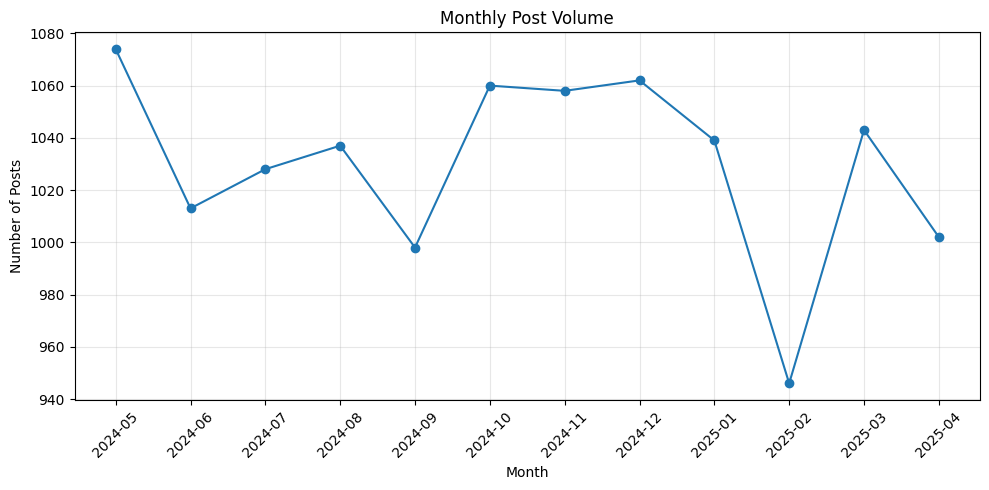

In [224]:
# STEP 28D — Monthly post volume

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_eda.index.astype(str),
    monthly_eda["posts"],
    marker="o"
)

plt.title("Monthly Post Volume")
plt.xlabel("Month")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

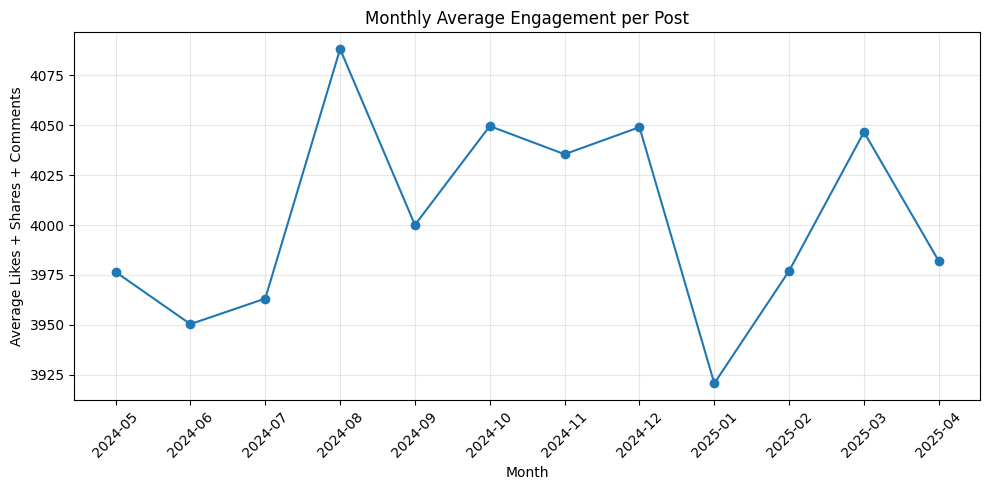

In [225]:
# STEP 28E — Monthly average engagement per post

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_eda.index.astype(str),
    monthly_eda["avg_total_engagement"],
    marker="o"
)

plt.title("Monthly Average Engagement per Post")
plt.xlabel("Month")
plt.ylabel("Average Likes + Shares + Comments")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [226]:
# STEP 29A — Day-of-week posting activity
# EDA only — no data is modified.

dow_eda = (
    posts_eda
    .assign(
        day_of_week=posts_eda["timestamp"].dt.day_name()
    )
    .groupby("day_of_week")
    .agg(
        posts=("post_id", "size")
    )
)

# Put days in calendar order
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

dow_eda = dow_eda.reindex(day_order)

dow_eda["post_share_%"] = (
    dow_eda["posts"]
    / len(posts_eda)
    * 100
).round(2)

print("===== DAY-OF-WEEK POSTING ACTIVITY =====")
display(dow_eda)

===== DAY-OF-WEEK POSTING ACTIVITY =====


,posts,post_share_%
day_of_week,,
Monday,1766,14.29
Tuesday,1722,13.93
Wednesday,1826,14.77
Thursday,1778,14.39
Friday,1777,14.38
Saturday,1727,13.97
Sunday,1764,14.27


In [227]:
# STEP 29B — Test whether posting volume differs by day of week
# EDA only — no data is modified.

from scipy.stats import chisquare

observed_posts = dow_eda["posts"].values

expected_posts = np.repeat(
    len(posts_eda) / 7,
    7
)

chi2, p_value = chisquare(
    observed_posts,
    f_exp=expected_posts
)

print("===== DAY-OF-WEEK POSTING TEST =====")
print("Chi-square statistic:", round(chi2, 4))
print("p-value:", round(p_value, 6))
print("Degrees of freedom:", len(observed_posts) - 1)

===== DAY-OF-WEEK POSTING TEST =====
Chi-square statistic: 4.1487
p-value: 0.65656
Degrees of freedom: 6


In [228]:
# STEP 30A — Day-of-week engagement analysis
# EDA only — no data is modified.

dow_engagement = (
    posts_eda
    .assign(
        day_of_week=posts_eda["timestamp"].dt.day_name()
    )
    .groupby("day_of_week")
    .agg(
        posts=("post_id", "size"),
        avg_likes=("likes", "mean"),
        median_likes=("likes", "median"),
        avg_shares=("shares", "mean"),
        avg_comments=("comments", "mean")
    )
)

dow_engagement["avg_total_engagement"] = (
    dow_engagement["avg_likes"]
    + dow_engagement["avg_shares"]
    + dow_engagement["avg_comments"]
)

dow_engagement = dow_engagement.reindex(day_order)

print("===== DAY-OF-WEEK ENGAGEMENT =====")
display(dow_engagement.round(2))

===== DAY-OF-WEEK ENGAGEMENT =====


,posts,avg_likes,median_likes,avg_shares,avg_comments,avg_total_engagement
day_of_week,,,,,,
Monday,1766,2494.99,2500.0,1011.53,499.42,4005.94
Tuesday,1722,2466.82,2500.0,999.25,517.39,3983.46
Wednesday,1826,2515.43,2500.0,1017.64,505.07,4038.14
Thursday,1778,2467.35,2500.0,997.58,506.18,3971.11
Friday,1777,2483.34,2500.0,991.58,494.78,3969.71
Saturday,1727,2500.70,2500.0,1001.54,505.73,4007.96
Sunday,1764,2527.30,2500.0,1021.46,500.38,4049.14


In [229]:
# STEP 30B — Test mean engagement differences across weekdays
# EDA only — no data is modified.

from scipy.stats import f_oneway

daily_engagement_groups = []

for day in day_order:
    values = (
        posts_eda.loc[
            posts_eda["timestamp"].dt.day_name() == day,
            ["likes", "shares", "comments"]
        ]
        .sum(axis=1)
    )
    
    daily_engagement_groups.append(values)

f_stat, p_value = f_oneway(*daily_engagement_groups)

print("===== ONE-WAY ANOVA: DAILY ENGAGEMENT =====")
print("F-statistic:", round(f_stat, 4))
print("p-value:", round(p_value, 6))

===== ONE-WAY ANOVA: DAILY ENGAGEMENT =====
F-statistic: 0.8016
p-value: 0.568456


In [230]:
# STEP 31A — Analyze post text length
# EDA only — no source values are modified.

posts_eda["text_length"] = (
    posts_eda["text_content"]
    .astype(str)
    .str.len()
)

text_length_summary = (
    posts_eda["text_length"]
    .describe()
)

print("===== POST TEXT LENGTH =====")
display(text_length_summary.to_frame("value"))

===== POST TEXT LENGTH =====


,value
count,12360.000000
mean,102.932120
std,39.724179
min,6.000000
25%,99.000000
50%,115.000000
75%,127.000000
max,172.000000


In [231]:
# STEP 31B — Identify originally missing text
# EDA only — no source data is modified.

posts_eda["text_was_missing"] = (
    posts_final_check["text_content"] == "No text content"
)

print("===== ORIGINAL TEXT STATUS =====")

print(
    "Original text available:",
    (~posts_eda["text_was_missing"]).sum()
)

print(
    "Original text missing/imputed:",
    posts_eda["text_was_missing"].sum()
)

print(
    "Percentage text originally missing:",
    round(
        posts_eda["text_was_missing"].mean() * 100,
        2
    ),
    "%"
)

===== ORIGINAL TEXT STATUS =====
Original text available: 10590
Original text missing/imputed: 1770
Percentage text originally missing: 14.32 %


In [232]:
# STEP 31C — Text length for genuine observed text only
# EDA only — no data is modified.

observed_text = posts_eda.loc[
    ~posts_eda["text_was_missing"],
    "text_content"
]

observed_text_length = observed_text.str.len()

print("===== GENUINE TEXT LENGTH =====")

print("Observed text records:", len(observed_text_length))

display(
    observed_text_length.describe().to_frame("text_length")
)

===== GENUINE TEXT LENGTH =====
Observed text records: 10590


,text_length
count,10590.000000
mean,117.628990
std,18.256908
min,6.000000
25%,107.000000
50%,118.000000
75%,129.000000
max,172.000000


In [233]:
# STEP 31D — Text length vs engagement
# Genuine observed text only.
# EDA only — no source data is modified.

text_engagement = posts_eda.loc[
    ~posts_eda["text_was_missing"],
    ["text_length", "likes", "shares", "comments"]
].copy()

text_engagement["total_engagement"] = (
    text_engagement["likes"]
    + text_engagement["shares"]
    + text_engagement["comments"]
)

print("Records used:", len(text_engagement))

print("\n===== SPEARMAN CORRELATION =====")

display(
    text_engagement[
        ["text_length", "likes", "shares", "comments", "total_engagement"]
    ].corr(method="spearman").round(4)
)

Records used: 10590

===== SPEARMAN CORRELATION =====


,text_length,likes,shares,comments,total_engagement
text_length,1.0000,-0.0020,-0.0216,-0.0089,-0.0138
likes,-0.0020,1.0000,0.0005,0.0150,0.8974
shares,-0.0216,0.0005,1.0000,0.0243,0.3745
comments,-0.0089,0.0150,0.0243,1.0000,0.2061
total_engagement,-0.0138,0.8974,0.3745,0.2061,1.0000


In [234]:
# STEP 32A — Detect hashtags and mentions in genuine post text
# EDA only — no data is modified.

content_analysis = posts_eda.loc[
    ~posts_eda["text_was_missing"]
].copy()

content_analysis["has_hashtag"] = (
    content_analysis["text_content"]
    .str.contains(r"#\w+", regex=True, na=False)
)

content_analysis["has_mention"] = (
    content_analysis["text_content"]
    .str.contains(r"@\w+", regex=True, na=False)
)

print("===== CONTENT FEATURE COUNTS =====")

print(
    "Genuine-text posts:",
    len(content_analysis)
)

print(
    "Posts containing hashtag:",
    content_analysis["has_hashtag"].sum()
)

print(
    "Posts containing mention:",
    content_analysis["has_mention"].sum()
)

print(
    "Posts with neither:",
    (
        ~content_analysis["has_hashtag"]
        & ~content_analysis["has_mention"]
    ).sum()
)

===== CONTENT FEATURE COUNTS =====
Genuine-text posts: 10590
Posts containing hashtag: 10520
Posts containing mention: 1415
Posts with neither: 70


In [235]:
# STEP 32B — Hashtag/mention combination analysis
# EDA only — no data is modified.

content_combinations = (
    content_analysis[
        ["has_hashtag", "has_mention"]
    ]
    .value_counts()
    .rename("post_count")
    .reset_index()
)

print("===== HASHTAG / MENTION COMBINATIONS =====")
display(content_combinations)

===== HASHTAG / MENTION COMBINATIONS =====


,has_hashtag,has_mention,post_count
0,True,False,9105
1,True,True,1415
2,False,False,70


In [236]:
# STEP 32C — Engagement by hashtag/mention group
# Genuine observed text only.
# EDA only — no data is modified.

def content_group(row):
    if row["has_hashtag"] and row["has_mention"]:
        return "Hashtag + Mention"
    elif row["has_hashtag"]:
        return "Hashtag Only"
    else:
        return "Neither"

content_analysis["content_group"] = (
    content_analysis.apply(content_group, axis=1)
)

content_group_summary = (
    content_analysis
    .groupby("content_group")
    .agg(
        posts=("post_id", "size"),
        avg_likes=("likes", "mean"),
        avg_shares=("shares", "mean"),
        avg_comments=("comments", "mean")
    )
)

content_group_summary["avg_total_engagement"] = (
    content_group_summary["avg_likes"]
    + content_group_summary["avg_shares"]
    + content_group_summary["avg_comments"]
)

content_group_summary = content_group_summary.sort_values(
    "avg_total_engagement",
    ascending=False
)

print("===== ENGAGEMENT BY CONTENT GROUP =====")
display(content_group_summary.round(2))

===== ENGAGEMENT BY CONTENT GROUP =====


,posts,avg_likes,avg_shares,avg_comments,avg_total_engagement
content_group,,,,,
Hashtag Only,9105,2501.45,1003.01,502.40,4006.87
Hashtag + Mention,1415,2421.40,1005.56,513.73,3940.69
Neither,70,2427.71,1031.00,456.16,3914.87


In [237]:
# STEP 32D — Test engagement differences across content groups
# EDA only — no data is modified.

content_engagement_groups = []

for group in [
    "Hashtag Only",
    "Hashtag + Mention",
    "Neither"
]:
    values = (
        content_analysis.loc[
            content_analysis["content_group"] == group,
            ["likes", "shares", "comments"]
        ]
        .sum(axis=1)
    )
    
    content_engagement_groups.append(values)

f_stat, p_value = f_oneway(
    *content_engagement_groups
)

print("===== ONE-WAY ANOVA: CONTENT GROUP ENGAGEMENT =====")
print("F-statistic:", round(f_stat, 4))
print("p-value:", round(p_value, 6))

===== ONE-WAY ANOVA: CONTENT GROUP ENGAGEMENT =====
F-statistic: 1.3351
p-value: 0.263166


In [238]:
# STEP 33A — Engagement anomaly baseline
# EDA only — no records are removed or modified.

posts_eda["total_engagement"] = (
    posts_eda["likes"]
    + posts_eda["shares"]
    + posts_eda["comments"]
)

print("===== TOTAL ENGAGEMENT DISTRIBUTION =====")
display(
    posts_eda["total_engagement"]
    .describe()
)

print("\n===== TOP 10 HIGHEST-ENGAGEMENT POSTS =====")

top_engagement = (
    posts_eda[
        [
            "post_id",
            "user_id",
            "platform",
            "timestamp",
            "likes",
            "shares",
            "comments",
            "total_engagement"
        ]
    ]
    .sort_values("total_engagement", ascending=False)
    .head(10)
)

display(top_engagement)

===== TOTAL ENGAGEMENT DISTRIBUTION =====


count    12360.000000
mean      4003.791909
std       1477.181715
min        153.000000
25%       2931.000000
50%       4008.000000
75%       5065.000000
max       7893.000000
Name: total_engagement, dtype: float64


===== TOP 10 HIGHEST-ENGAGEMENT POSTS =====


,post_id,user_id,platform,timestamp,likes,shares,comments,total_engagement
12227,ycjj5zzt7mvx,user_d9971ba6,Instagram,2025-02-19 05:57:35,4983.0,1919,991,7893.0
3675,wo7py9aljg3t,user_o8le7hqf,Reddit,2025-04-28 00:00:00,4864.0,1981,948,7793.0
10583,gmoeib832zbs,user_pe5yckyb,Facebook,2025-01-24 10:39:09,4902.0,1880,982,7764.0
3350,5kvuyvf38nqx,user_z0feut2e,YouTube,2024-06-09 00:00:00,4923.0,1971,861,7755.0
8889,pvfl3d8hj7jd,user_csluibwk,Instagram,2024-05-15 00:00:00,4989.0,1840,909,7738.0
8578,tdgjjylpua20,user_8nvzxsuj,Unknown,2024-06-02 00:00:00,4979.0,1932,812,7723.0
5201,tne7s3o4l4wd,user_lr3fagdl,Instagram,2024-10-30 11:45:55,4931.0,1903,878,7712.0
6738,a1kiwl618kzy,user_aaiari8o,Facebook,2025-04-09 00:00:00,4811.0,1952,920,7683.0
8934,fp89q1ickn9w,user_h4lueh1i,Twitter,2025-03-15 18:19:33,4740.0,1933,955,7628.0
6646,5n161ir5hhhr,user_u98jwp3f,YouTube,2025-01-26 00:44:23,4751.0,1981,878,7610.0


In [239]:
# STEP 33B — IQR-based engagement outlier detection
# EDA only — no records are modified.

Q1 = posts_eda["total_engagement"].quantile(0.25)
Q3 = posts_eda["total_engagement"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (
    (posts_eda["total_engagement"] < lower_bound)
    | (posts_eda["total_engagement"] > upper_bound)
)

print("===== IQR OUTLIER ANALYSIS =====")
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

print("\nLower bound:", lower_bound)
print("Upper bound:", upper_bound)

print("\nNumber of outliers:", outlier_mask.sum())
print(
    "Percentage of records:",
    round(outlier_mask.mean() * 100, 2),
    "%"
)

===== IQR OUTLIER ANALYSIS =====
Q1: 2931.0
Q3: 5065.0
IQR: 2134.0

Lower bound: -270.0
Upper bound: 8266.0

Number of outliers: 0
Percentage of records: 0.0 %


In [240]:
# STEP 34A — Individual engagement outlier analysis
# EDA only — no data is modified.

metrics = ["likes", "shares", "comments"]

outlier_results = []

for metric in metrics:
    Q1 = posts_eda[metric].quantile(0.25)
    Q3 = posts_eda[metric].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = (
        (posts_eda[metric] < lower_bound)
        | (posts_eda[metric] > upper_bound)
    )

    outlier_results.append({
        "metric": metric,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": int(outlier_mask.sum()),
        "outlier_%": round(
            outlier_mask.mean() * 100, 2
        )
    })

individual_outliers = pd.DataFrame(outlier_results)

print("===== INDIVIDUAL ENGAGEMENT OUTLIERS =====")
display(individual_outliers.round(2))

===== INDIVIDUAL ENGAGEMENT OUTLIERS =====


,metric,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_%
0,likes,1467.0,3520.25,2053.25,-1612.88,6600.12,0,0.0
1,shares,509.0,1499.00,990.00,-976.00,2984.00,0,0.0
2,comments,252.0,755.00,503.00,-502.50,1509.50,0,0.0


In [241]:
# STEP 35A — User-level engagement summary
# EDA only — no data is modified.

user_engagement = (
    posts_eda
    .groupby("user_id")
    .agg(
        posts=("post_id", "size"),
        total_likes=("likes", "sum"),
        total_shares=("shares", "sum"),
        total_comments=("comments", "sum"),
        avg_likes=("likes", "mean"),
        avg_shares=("shares", "mean"),
        avg_comments=("comments", "mean")
    )
)

user_engagement["avg_total_engagement"] = (
    user_engagement["avg_likes"]
    + user_engagement["avg_shares"]
    + user_engagement["avg_comments"]
)

print("===== USER-LEVEL ENGAGEMENT =====")
print("Users:", len(user_engagement))

display(
    user_engagement.describe().round(2)
)

===== USER-LEVEL ENGAGEMENT =====
Users: 1500


,posts,total_likes,total_shares,total_comments,avg_likes,avg_shares,avg_comments,avg_total_engagement
count,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00
mean,8.24,20549.26,8288.35,4153.64,2486.50,1008.79,505.06,4000.35
std,2.95,8422.67,3388.96,1706.42,513.95,219.73,112.01,570.69
min,1.00,206.00,941.00,203.00,103.00,279.17,101.50,1686.50
25%,6.00,14356.25,5809.00,2888.50,2169.86,865.62,432.34,3609.25
50%,8.00,20136.50,8023.50,4047.50,2494.90,1003.05,501.78,4009.65
75%,10.00,25813.50,10458.00,5196.25,2828.67,1148.50,576.00,4396.07
max,22.00,55642.00,23066.00,12016.00,4010.33,1929.00,999.00,5898.67


In [242]:
# STEP 36A — Merge user attributes with engagement
# EDA only — source datasets are not modified.

user_eda = (
    user_engagement
    .reset_index()
    .merge(
        users_raw[
            [
                "user_id",
                "location",
                "language",
                "follower_count"
            ]
        ],
        on="user_id",
        how="left",
        validate="one_to_one"
    )
)

print("===== USER EDA MERGE =====")

print("Rows:", len(user_eda))
print("Columns:", len(user_eda.columns))

print("\nMissing follower counts:",
      user_eda["follower_count"].isna().sum())

print("Missing locations:",
      user_eda["location"].isna().sum())

print("Missing languages:",
      user_eda["language"].isna().sum())

print("\nUnique users:",
      user_eda["user_id"].nunique())

===== USER EDA MERGE =====
Rows: 1500
Columns: 12

Missing follower counts: 0
Missing locations: 0
Missing languages: 0

Unique users: 1500


In [243]:
# STEP 36B — Follower count vs average engagement
# EDA only — no data is modified.

from scipy.stats import pearsonr, spearmanr

x = user_eda["follower_count"]
y = user_eda["avg_total_engagement"]

pearson_r, pearson_p = pearsonr(x, y)
spearman_rho, spearman_p = spearmanr(x, y)

print("===== FOLLOWER COUNT VS AVERAGE ENGAGEMENT =====")

print(
    "Pearson correlation:",
    round(pearson_r, 4),
    "| p-value:",
    round(pearson_p, 6)
)

print(
    "Spearman correlation:",
    round(spearman_rho, 4),
    "| p-value:",
    round(spearman_p, 6)
)

===== FOLLOWER COUNT VS AVERAGE ENGAGEMENT =====
Pearson correlation: -0.0017 | p-value: 0.947942
Spearman correlation: 0.0047 | p-value: 0.856526


In [244]:
# STEP 37A — User location distribution
# EDA only — no data is modified.

location_summary = (
    user_eda
    .groupby("location")
    .agg(
        users=("user_id", "size"),
        avg_followers=("follower_count", "mean"),
        avg_engagement=("avg_total_engagement", "mean")
    )
    .sort_values("users", ascending=False)
)

print("===== USER LOCATION DISTRIBUTION =====")

print("Number of locations:",
      len(location_summary))

print("\nTop locations by user count:")
display(location_summary.head(15).round(2))

===== USER LOCATION DISTRIBUTION =====
Number of locations: 33

Top locations by user count:


,users,avg_followers,avg_engagement
location,,,
"Barcelona, Spain",56,23975.64,4050.54
"Shanghai, China",56,25598.88,4010.75
"Los Angeles, USA",55,26201.47,3981.93
"Munich, Germany",54,23353.89,3979.99
"Dubai, UAE",53,25724.26,4042.51
"Milan, Italy",53,23871.02,3918.57
"Mumbai, India",53,24430.09,3858.73
"Melbourne, Australia",52,27374.83,4090.42
"Beijing, China",51,25221.06,4074.26


In [245]:
# STEP 37B — Check location sample sizes
# EDA only — no data is modified.

location_counts = (
    user_eda["location"]
    .value_counts()
    .sort_values()
)

print("===== LOCATION SAMPLE SIZE CHECK =====")

print("Number of locations:", len(location_counts))
print("Minimum users in a location:", location_counts.min())
print("Maximum users in a location:", location_counts.max())
print("Median users per location:", location_counts.median())

print("\nLocations with fewer than 30 users:")
display(
    location_counts[
        location_counts < 30
    ].to_frame("users")
)

print("\nAll location counts:")
display(
    location_counts.to_frame("users")
)

===== LOCATION SAMPLE SIZE CHECK =====
Number of locations: 33
Minimum users in a location: 28
Maximum users in a location: 56
Median users per location: 45.0

Locations with fewer than 30 users:


,users
location,
"Sydney, Australia",28



All location counts:


,users
location,
"Sydney, Australia",28
"Lagos, Nigeria",30
"Seoul, South Korea",36
"Madrid, Spain",36
"Lyon, France",37
"Vancouver, Canada",38
"Delhi, India",39
"Cairo, Egypt",39
"Mexico City, Mexico",40


In [246]:
# STEP 37C — Location-level engagement comparison
# EDA only — no data is modified.

location_engagement = (
    user_eda
    .groupby("location")
    .agg(
        users=("user_id", "size"),
        avg_followers=("follower_count", "mean"),
        avg_engagement=("avg_total_engagement", "mean")
    )
    .sort_values("avg_engagement", ascending=False)
)

print("===== LOCATION ENGAGEMENT =====")

display(
    location_engagement.round(2)
)

===== LOCATION ENGAGEMENT =====


,users,avg_followers,avg_engagement
location,,,
"Delhi, India",39,29381.23,4098.48
Singapore,49,24612.20,4097.41
"Melbourne, Australia",52,27374.83,4090.42
"Cairo, Egypt",39,21908.77,4085.24
"Sydney, Australia",28,26618.07,4082.20
"Beijing, China",51,25221.06,4074.26
"Paris, France",45,24723.18,4070.33
"Osaka, Japan",50,27564.50,4068.17
"Barcelona, Spain",56,23975.64,4050.54


In [247]:
# STEP 37D — Identify exact location engagement extremes
# EDA only — no data is modified.

highest_location = location_engagement["avg_engagement"].idxmax()
lowest_location = location_engagement["avg_engagement"].idxmin()

print("===== LOCATION ENGAGEMENT EXTREMES =====")

print(
    "Highest:",
    highest_location,
    "| Users:",
    location_engagement.loc[highest_location, "users"],
    "| Avg engagement:",
    round(
        location_engagement.loc[
            highest_location, "avg_engagement"
        ],
        2
    )
)

print(
    "Lowest:",
    lowest_location,
    "| Users:",
    location_engagement.loc[lowest_location, "users"],
    "| Avg engagement:",
    round(
        location_engagement.loc[
            lowest_location, "avg_engagement"
        ],
        2
    )
)

print("\nDifference:")
print(
    round(
        location_engagement["avg_engagement"].max()
        - location_engagement["avg_engagement"].min(),
        2
    )
)

===== LOCATION ENGAGEMENT EXTREMES =====
Highest: Delhi, India | Users: 39 | Avg engagement: 4098.48
Lowest: Vancouver, Canada | Users: 38 | Avg engagement: 3823.6

Difference:
274.88


In [248]:
# STEP 37E — Test whether engagement differs by location
# EDA only — no data is modified.

location_groups = [
    group["avg_total_engagement"].values
    for _, group in user_eda.groupby("location")
]

f_stat, p_value = f_oneway(*location_groups)

print("===== ONE-WAY ANOVA: LOCATION ENGAGEMENT =====")
print("F-statistic:", round(f_stat, 4))
print("p-value:", round(p_value, 6))
print("Number of locations:", len(location_groups))

===== ONE-WAY ANOVA: LOCATION ENGAGEMENT =====
F-statistic: 0.7559
p-value: 0.835694
Number of locations: 33


In [249]:
# STEP 38A — User language distribution
# EDA only — no data is modified.

language_counts = (
    user_eda["language"]
    .value_counts()
    .sort_values(ascending=False)
)

print("===== LANGUAGE DISTRIBUTION =====")

print("Number of languages:", len(language_counts))
print("Minimum users/language:", language_counts.min())
print("Maximum users/language:", language_counts.max())
print("Median users/language:", language_counts.median())

display(
    language_counts.to_frame("users")
)

===== LANGUAGE DISTRIBUTION =====
Number of languages: 10
Minimum users/language: 141
Maximum users/language: 168
Median users/language: 148.0


,users
language,
zh,168
hi,156
ja,156
en,153
fr,150
es,146
ru,144
pt,143
ar,143


In [250]:
# STEP 38B — Language-level engagement
# EDA only — no data is modified.

language_engagement = (
    user_eda
    .groupby("language")
    .agg(
        users=("user_id", "size"),
        avg_followers=("follower_count", "mean"),
        avg_engagement=("avg_total_engagement", "mean")
    )
    .sort_values("avg_engagement", ascending=False)
)

print("===== LANGUAGE ENGAGEMENT =====")
display(language_engagement.round(2))

===== LANGUAGE ENGAGEMENT =====


,users,avg_followers,avg_engagement
language,,,
en,153,27000.54,4071.26
ar,143,25584.81,4054.91
pt,143,26066.38,4036.31
zh,168,25028.33,4016.30
de,141,21692.05,3996.24
ja,156,24547.73,3995.01
ru,144,26453.28,3983.74
es,146,22963.95,3983.64
fr,150,25128.08,3973.76


In [251]:
# STEP 38C — Test engagement differences across languages
# EDA only — no data is modified.

language_groups = [
    group["avg_total_engagement"].values
    for _, group in user_eda.groupby("language")
]

f_stat, p_value = f_oneway(*language_groups)

print("===== ONE-WAY ANOVA: LANGUAGE ENGAGEMENT =====")
print("F-statistic:", round(f_stat, 4))
print("p-value:", round(p_value, 6))
print("Number of languages:", len(language_groups))

===== ONE-WAY ANOVA: LANGUAGE ENGAGEMENT =====
F-statistic: 1.1293
p-value: 0.338218
Number of languages: 10


In [252]:
# STEP 39A — Engagement composition
# EDA only — no data is modified.

engagement_composition = posts_eda[
    ["likes", "shares", "comments"]
].copy()

engagement_composition["total_engagement"] = (
    engagement_composition["likes"]
    + engagement_composition["shares"]
    + engagement_composition["comments"]
)

engagement_composition["like_share_%"] = (
    engagement_composition["likes"]
    / engagement_composition["total_engagement"]
    * 100
)

engagement_composition["share_share_%"] = (
    engagement_composition["shares"]
    / engagement_composition["total_engagement"]
    * 100
)

engagement_composition["comment_share_%"] = (
    engagement_composition["comments"]
    / engagement_composition["total_engagement"]
    * 100
)

print("===== ENGAGEMENT COMPOSITION =====")

display(
    engagement_composition[
        [
            "like_share_%",
            "share_share_%",
            "comment_share_%"
        ]
    ].describe().round(2)
)

===== ENGAGEMENT COMPOSITION =====


,like_share_%,share_share_%,comment_share_%
count,12360.00,12360.00,12360.00
mean,58.71,26.96,14.33
std,20.11,16.81,10.64
min,0.00,0.00,0.00
25%,48.92,14.51,6.77
50%,62.23,25.21,12.62
75%,72.75,36.03,18.92
max,99.35,98.61,85.22


In [253]:
# STEP 40A — Engagement composition using originally observed likes only
# EDA only — no data is modified.

observed_likes_mask = posts_raw["likes"].notna()

observed_composition = posts_raw.loc[
    observed_likes_mask,
    ["likes", "shares", "comments"]
].copy()

observed_composition["total_engagement"] = (
    observed_composition["likes"]
    + observed_composition["shares"]
    + observed_composition["comments"]
)

observed_composition["like_share_%"] = (
    observed_composition["likes"]
    / observed_composition["total_engagement"]
    * 100
)

observed_composition["share_share_%"] = (
    observed_composition["shares"]
    / observed_composition["total_engagement"]
    * 100
)

observed_composition["comment_share_%"] = (
    observed_composition["comments"]
    / observed_composition["total_engagement"]
    * 100
)

print("===== OBSERVED-LIKES ENGAGEMENT COMPOSITION =====")
print("Records with originally observed likes:",
      len(observed_composition))

display(
    observed_composition[
        [
            "like_share_%",
            "share_share_%",
            "comment_share_%"
        ]
    ].describe().round(2)
)

===== OBSERVED-LIKES ENGAGEMENT COMPOSITION =====
Records with originally observed likes: 10502


,like_share_%,share_share_%,comment_share_%
count,10502.00,10502.00,10502.00
mean,40.42,33.64,25.94
std,1136.47,498.75,864.12
min,-86100.00,-4781.82,-3481.82
25%,45.00,13.37,6.13
50%,62.69,24.83,12.37
75%,74.14,37.41,19.35
max,8363.64,37325.00,83200.00


In [254]:
# STEP 40B — Engagement composition using originally valid likes
# EDA only — no data is modified.

valid_original_likes = (
    posts_raw["likes"].notna()
    & (posts_raw["likes"] >= 0)
)

observed_valid_composition = posts_raw.loc[
    valid_original_likes,
    ["likes", "shares", "comments"]
].copy()

observed_valid_composition["total_engagement"] = (
    observed_valid_composition["likes"]
    + observed_valid_composition["shares"]
    + observed_valid_composition["comments"]
)

observed_valid_composition["like_share_%"] = (
    observed_valid_composition["likes"]
    / observed_valid_composition["total_engagement"]
    * 100
)

observed_valid_composition["share_share_%"] = (
    observed_valid_composition["shares"]
    / observed_valid_composition["total_engagement"]
    * 100
)

observed_valid_composition["comment_share_%"] = (
    observed_valid_composition["comments"]
    / observed_valid_composition["total_engagement"]
    * 100
)

print("===== VALID ORIGINAL-LIKES COMPOSITION =====")
print(
    "Records used:",
    len(observed_valid_composition)
)

display(
    observed_valid_composition[
        [
            "like_share_%",
            "share_share_%",
            "comment_share_%"
        ]
    ].describe().round(2)
)

===== VALID ORIGINAL-LIKES COMPOSITION =====
Records used: 9977


,like_share_%,share_share_%,comment_share_%
count,9977.00,9977.00,9977.00
mean,57.76,27.62,14.62
std,21.21,17.55,11.10
min,0.00,0.00,0.00
25%,45.26,14.51,6.76
50%,62.21,25.26,12.58
75%,73.04,37.27,19.30
max,99.35,98.61,85.22


In [255]:
# STEP 41 — Freeze final EDA dataset

posts_final_check.to_csv(
    OUTPUT_PATH,
    index=False
)

print("FINAL CLEAN DATASET READY")
print("File:", OUTPUT_PATH)
print("Rows:", len(posts_final_check))
print("Columns:", len(posts_final_check.columns))

FINAL CLEAN DATASET READY
File: c:\Users\Aryan Kishore\OneDrive\Desktop\QUANTUM ALPHA\DATA_VORTEX\Social_Engine_Posts_Cleaned.csv
Rows: 12360
Columns: 10
